In [1]:
import sys

sys.path.append("../src/")
import matplotlib.pyplot as plt
import torch

from cryosim.icemaker import Icemaker
from cryosim.plotting_tools import plot3d, radial_distribution_function

%load_ext autoreload
%autoreload 2

In [2]:
dx_md = 0.25
n_md = 400
im_md = Icemaker(dx=dx_md, n=n_md)
source = "dump"
filepath = "/scratch/loh/joel/czii/stackingDisordered_20x20x20.MW_temp400.dump"

im_md.get_mdsim(filepath, startframe=10, endframe=11)

12928909it [00:01, 8839875.58it/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.84s/it]


In [3]:
mdsim_ice_coordinates = torch.stack(im_md.mdsim_ice_coordinates)
mdsim_ice_coordinates.shape

torch.Size([1, 31424, 3])

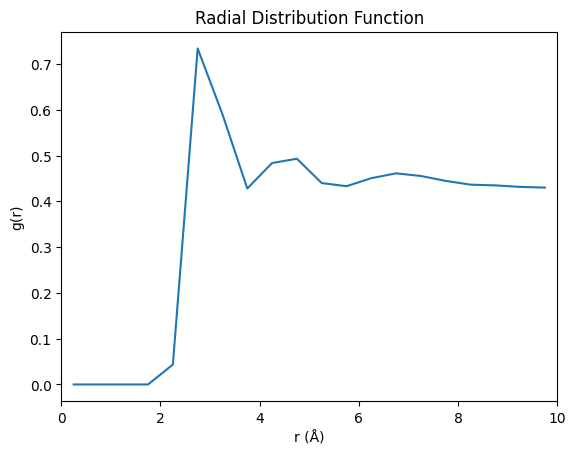

In [4]:
r_md, gr_md = radial_distribution_function(
    im_md.mdsim_ice_coordinates[0], (n_md * dx_md) ** 3, dr=0.5, r_max=10
)

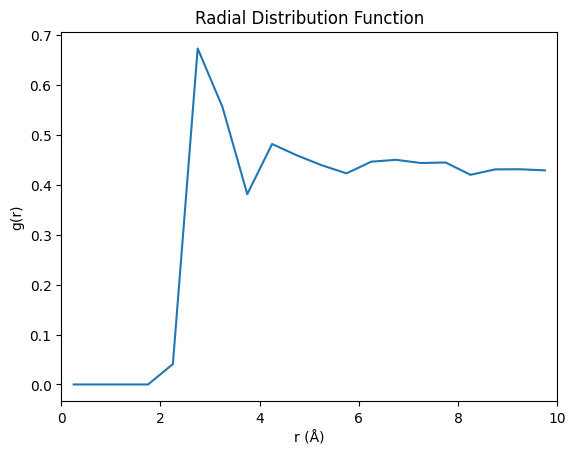

In [5]:
r_md, gr_md = radial_distribution_function(
    im_md.mdsim_ice_coordinates[0],
    (n_md * dx_md) ** 3,
    dr=0.5,
    r_max=10,
    # chunk_size=5000,
    n_samples=5000000,
    approximate=True,
)

## Ice maker

In [7]:
dx = 1
n = 256
ice_thickness = None  # A
batchsize = 5
im = Icemaker(dx=dx, n=n).to("cuda")
saved_data_path = "../ice-data/mdsim_f_radial_avg_400x400x400_0.25A.pt"
# im.generate_ice_deltas(min_distance=1.9, niter=5, batchsize=batchsize)
# ice_cubes = im.generate_ice(batchsize=batchsize)
with torch.no_grad():
    ice_cubes = im.generate_ice(batchsize)

 60%|█████████████████████████████████████████████████████████████████████████████████████▏                                                        | 3/5 [00:02<00:01,  1.42it/s]

Stopping. Converged at iteration 3.


In [8]:
im.current_icedeltas.device

device(type='cuda', index=0)

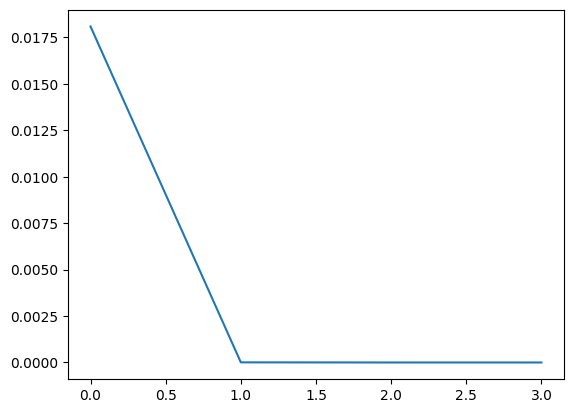

In [9]:
plt.plot(im.frob_norm)

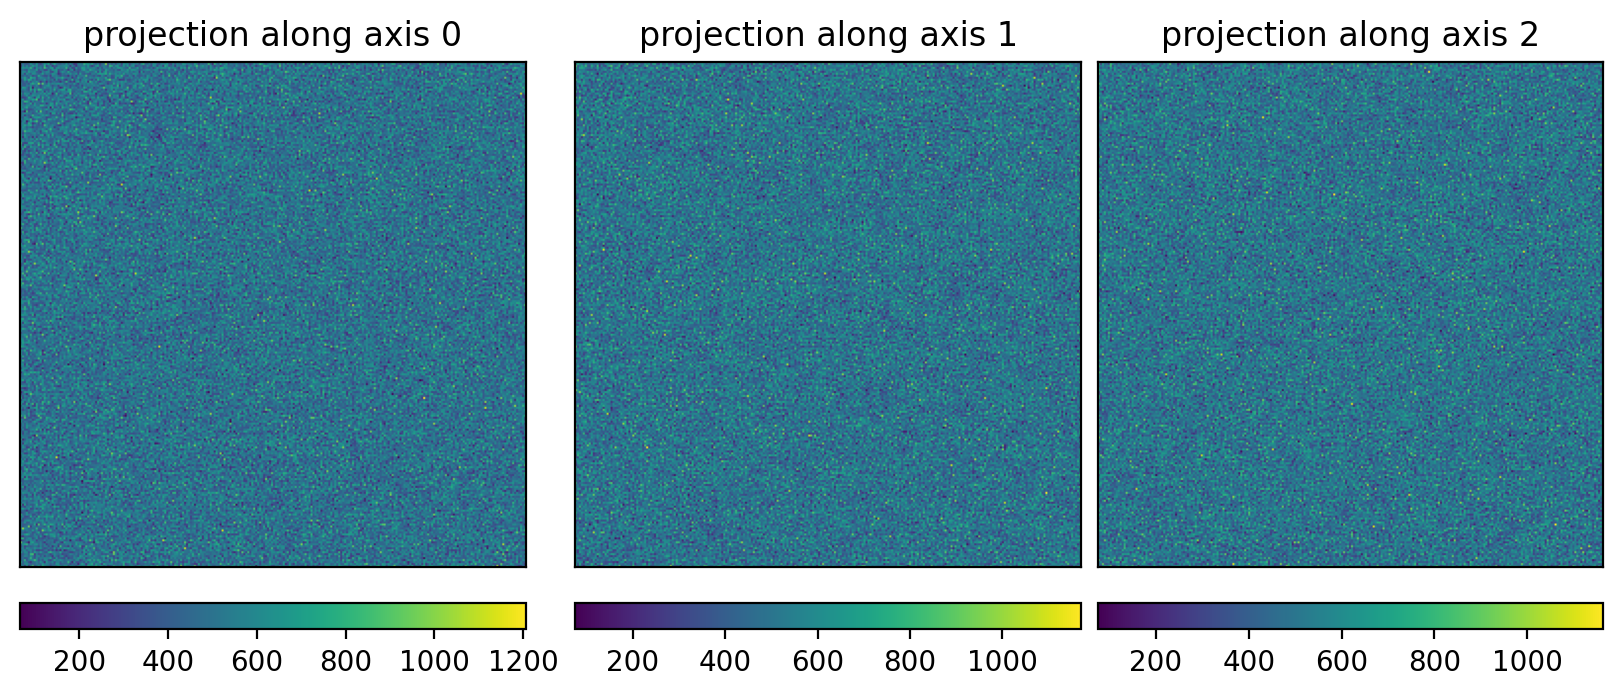

In [10]:
plot3d(ice_cubes[1].cpu())

In [11]:
im.n_ice_molecules, im.n_peaks

(527178, 527178)

In [12]:
im.ice_coordinates.shape

torch.Size([5, 527178, 3])

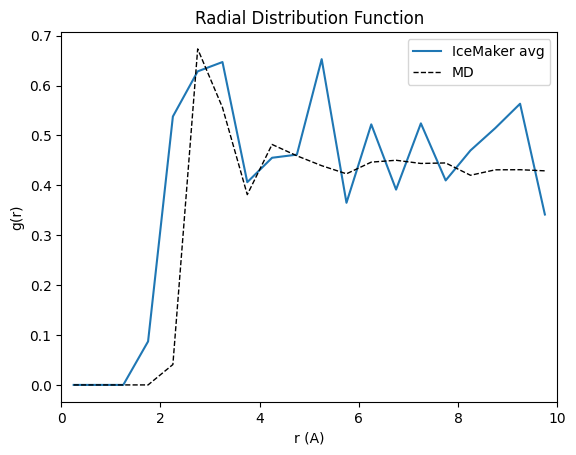

In [13]:
grs = []
for ic in im.ice_coordinates:
    r, gr = radial_distribution_function(
        ic.type(torch.float) * dx,
        (n * dx) ** 3,
        dr=0.5,
        r_max=10,
        # chunk_size=5000,
        n_samples=5000000,
        approximate=True,
        plot=False,
    )
    # plt.plot(r, gr, label="IceMaker")
    grs.append(gr)

plt.plot(r_md, torch.mean(torch.stack(grs), dim=0), label="IceMaker avg")
plt.plot(r_md, gr_md, label="MD", color="k", lw=1, ls="--")
plt.xlabel("r (A)")
plt.ylabel("g(r)")
plt.title("Radial Distribution Function")
plt.xlim([0, 10])
plt.legend()
plt.show()